In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import numpy as np


# Load the amortization results (one build query maintaining N synopses). The existing plots below filter
# to num_synopses == 1 to recover the single-synopsis view; the amortization cell (last) uses the
# num_synopses > 1 rows. This is the only accepted input — error out if the benchmark has not produced it.
_AMORT_CSV = "results_synopsis_amortization.csv"
if not os.path.exists(_AMORT_CSV):
    raise FileNotFoundError(
        f"{_AMORT_CSV} not found in {os.getcwd()}. Run the synopsis-amortization benchmark first "
        "(scripts/benchmarking/statistic_build_probe/run_statistic_build_probe.sh), then copy/point to its CSV."
    )
print(f"Loading {_AMORT_CSV}")
df = pd.read_csv(_AMORT_CSV)
df['system'] = 'NebulaStream'

# num_synopses = how many synopses one build query maintained.
df['num_synopses'] = pd.to_numeric(df['num_synopses'], errors='coerce').fillna(1).astype(int)

# Backward-compat alias: tuplesPerSecond_listener is the throughput column name
# from the new accuracy-aware build runner.
if 'tuplesPerSecond' not in df.columns and 'tuplesPerSecond_listener' in df.columns:
    df['tuplesPerSecond'] = df['tuplesPerSecond_listener']

# Extract synopsis type and variant from query_name
df["synopsis_type"] = df["query_name"].str.split("_").str[0]
df["query_variant"] = df["query_name"].str.split("_", n=1).str[1]

# Parse memory_budget into dedicated columns per statistic type.
mask_res = df["statistic_type"] == "Reservoir"
try:
    df.loc[mask_res, "reservoir_size"] = df.loc[mask_res, "memory_budget"].astype(int)
except (ValueError, KeyError):
    pass

mask_hist = df["statistic_type"] == "EquiWidthHistogram"
try:
    df.loc[mask_hist, "num_buckets"] = (
        df.loc[mask_hist, "memory_budget"]
        .str.extract(r"\((\d+),")[0].astype(int)
    )
except (ValueError, KeyError, AttributeError):
    pass

# df_ok: the single-synopsis (num_synopses == 1) ok-issue subset with throughput
# and accuracy coerced to numeric. Used by every build/overhead plotting cell below.
df_ok = df[(df["issue"] == "ok") & (df["num_synopses"] == 1)].copy()
df_ok["tuplesPerSecond"] = pd.to_numeric(df_ok["tuplesPerSecond"], errors="coerce")
for _col in ("point_avg_relative_error", "range_avg_relative_error"):
    if _col in df_ok.columns:
        df_ok[_col] = pd.to_numeric(df_ok[_col], errors="coerce")

df

Loading results_synopsis_amortization.csv


,dataset,statistic_type,memory_budget,build_window_size_sec,executionMode,numberOfWorkerThreads,buffersInGlobalBufferManager,joinStrategy,bufferSizeInBytes,pageSize,...,num_synopses,query_name,tuplesPerSecond_listener,build_duration_s,issue,system,tuplesPerSecond,synopsis_type,query_variant,reservoir_size
0,ClusterMonitoring,CountMin,1024,1,COMPILER,1,200000,HASH_JOIN,102400,8192,...,1,CountMinAmort_ClusterMonitoring_N1_mb1024_1sec,2.108202e+06,16.126358,ok,NebulaStream,2.108202e+06,CountMinAmort,ClusterMonitoring_N1_mb1024_1sec,NaN
1,ClusterMonitoring,CountMin,1024,1,COMPILER,1,200000,HASH_JOIN,102400,8192,...,1,CountMinAmort_ClusterMonitoring_N1_mb1024_1sec,2.115193e+06,16.124045,ok,NebulaStream,2.115193e+06,CountMinAmort,ClusterMonitoring_N1_mb1024_1sec,NaN
2,ClusterMonitoring,CountMin,1024,1,COMPILER,1,200000,HASH_JOIN,102400,8192,...,1,CountMinAmort_ClusterMonitoring_N1_mb1024_1sec,2.085017e+06,16.130275,ok,NebulaStream,2.085017e+06,CountMinAmort,ClusterMonitoring_N1_mb1024_1sec,NaN
3,ClusterMonitoring,CountMin,10240,1,COMPILER,1,200000,HASH_JOIN,102400,8192,...,1,CountMinAmort_ClusterMonitoring_N1_mb10240_1sec,1.537680e+06,19.374459,ok,NebulaStream,1.537680e+06,CountMinAmort,ClusterMonitoring_N1_mb10240_1sec,NaN
4,ClusterMonitoring,CountMin,10240,1,COMPILER,1,200000,HASH_JOIN,102400,8192,...,1,CountMinAmort_ClusterMonitoring_N1_mb10240_1sec,1.552575e+06,19.129320,ok,NebulaStream,1.552575e+06,CountMinAmort,ClusterMonitoring_N1_mb10240_1sec,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
571,Manufacturing,Sum,1024,10,COMPILER,16,200000,HASH_JOIN,102400,8192,...,1,SumAmort_Manufacturing_N1_mb1024_10sec,6.059500e+07,4.881278,ok,NebulaStream,6.059500e+07,SumAmort,Manufacturing_N1_mb1024_10sec,NaN
572,Manufacturing,Sum,1024,10,COMPILER,16,200000,HASH_JOIN,102400,8192,...,1,SumAmort_Manufacturing_N1_mb1024_10sec,4.541400e+07,4.898352,ok,NebulaStream,4.541400e+07,SumAmort,Manufacturing_N1_mb1024_10sec,NaN
573,Manufacturing,Passthrough,1024,10,COMPILER,16,200000,HASH_JOIN,102400,8192,...,1,PassthroughAmort_Manufacturing_N1_mb1024_10sec,-1.000000e+00,4.785967,ok,NebulaStream,-1.000000e+00,PassthroughAmort,Manufacturing_N1_mb1024_10sec,NaN
574,Manufacturing,Passthrough,1024,10,COMPILER,16,200000,HASH_JOIN,102400,8192,...,1,PassthroughAmort_Manufacturing_N1_mb1024_10sec,-1.000000e+00,4.803362,ok,NebulaStream,-1.000000e+00,PassthroughAmort,Manufacturing_N1_mb1024_10sec,NaN


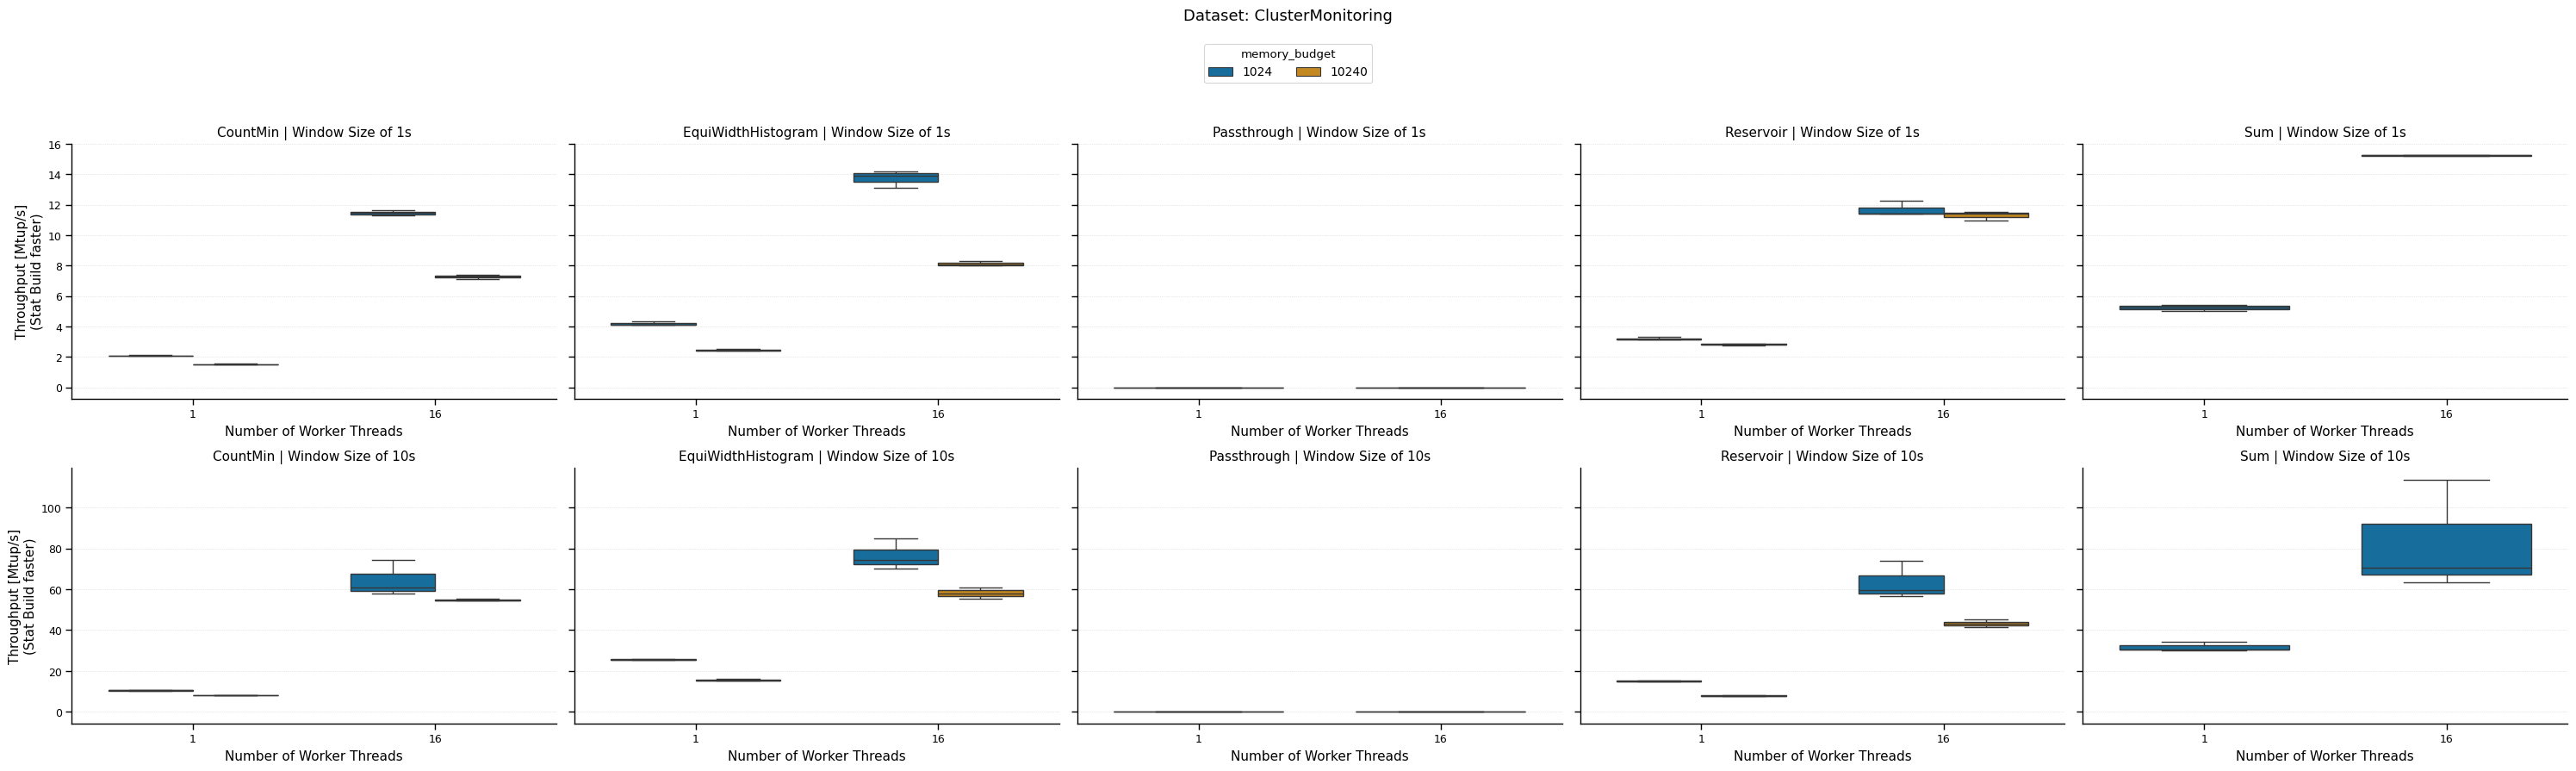

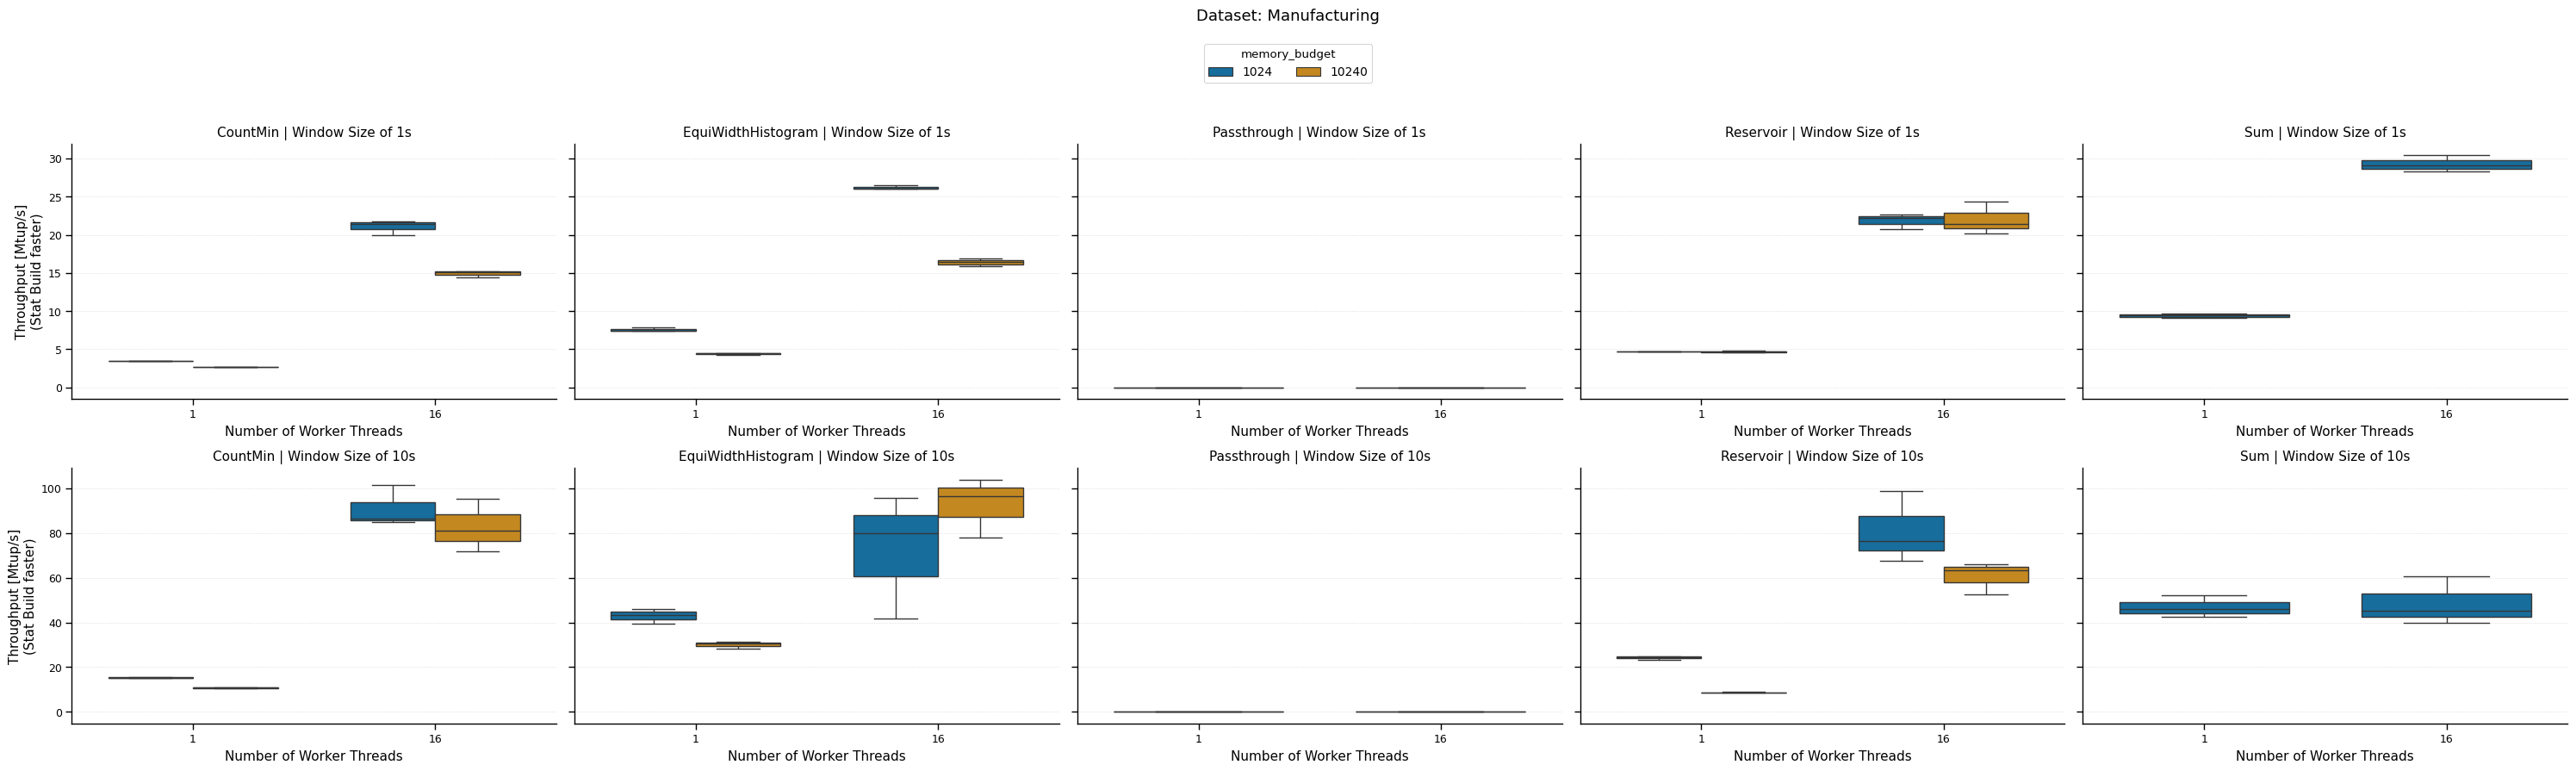

In [2]:
# For each unique dataset, plot a grid:
#   rows = build_window_size_sec, cols = statistic_type
#   x = numberOfWorkerThreads, y = tuplesPerSecond / 1e6 (in Mtup/s)
# Boxplot per (memory_budget, threads) cell shows median + IQR + whiskers across the runs.
# num_synopses == 1 keeps this the single-synopsis view (the amortization CSV also holds N > 1 rows).

df_ok = df[(df["issue"] == "ok") & (df["num_synopses"] == 1)].copy()
df_ok["tuplesPerSecond"] = pd.to_numeric(df_ok["tuplesPerSecond"], errors="coerce")
df_ok = df_ok.dropna(subset=["tuplesPerSecond"])

# Convert throughput to Mtup/s (divide by 1e6)
df_ok["throughput_mtp_s"] = df_ok["tuplesPerSecond"] / 1e6

for dataset in sorted(df_ok["dataset"].unique()):
    df_ds = df_ok[df_ok["dataset"] == dataset]

    window_sizes = sorted(df_ds["build_window_size_sec"].unique())
    statistic_types = sorted(df_ds["statistic_type"].unique())

    n_rows = len(window_sizes)
    n_cols = len(statistic_types)

    with sns.plotting_context("paper", rc={
          "axes.labelsize": 11, "axes.titlesize": 12, "legend.fontsize": 10,
          "xtick.labelsize": 9, "ytick.labelsize": 9,
      }):
        fig, axes = plt.subplots(
            n_rows, n_cols,
            figsize=(6 * n_cols, 4.5 * n_rows),
            sharey='row',
            squeeze=False,
          )

        legend_handles, legend_labels = None, None

        for row_idx, window_size in enumerate(window_sizes):
            for col_idx, stat_type in enumerate(statistic_types):
                ax = axes[row_idx][col_idx]
                subset = df_ds[
                      (df_ds["build_window_size_sec"] == window_size)
                      & (df_ds["statistic_type"] == stat_type)
                  ]

                if subset.empty:
                    ax.set_visible(False)
                    continue

                hue_order = sorted(subset["memory_budget"].dropna().unique())
                palette = sns.color_palette("colorblind", n_colors=len(hue_order))
                sns.boxplot(
                    data=subset,
                    x="numberOfWorkerThreads",
                    y="throughput_mtp_s",
                    hue="memory_budget",
                    hue_order=hue_order,
                    palette=palette,
                    width=0.7, fliersize=0,
                    ax=ax,
                  )

                ax.set_title(f"{stat_type} | Window Size of {window_size}s", fontsize=11)
                ax.set_xlabel("Number of Worker Threads")
                if col_idx == 0:
                    ax.set_ylabel("Throughput [Mtup/s]\n(Stat Build faster)")
                ax.grid(True, axis="y", linestyle=":", linewidth=0.5, alpha=0.6)
                sns.despine(ax=ax)
                handles, labels = ax.get_legend_handles_labels()
                if legend_handles is None or len(labels) > len(legend_labels):
                    legend_handles, legend_labels = handles, labels
                legend = ax.get_legend()
                if legend is not None:
                    legend.remove()

        fig_height = fig.get_figheight()
        top_reserve = 1.0 / fig_height
        if legend_handles:
            fig.legend(
                legend_handles,
                legend_labels,
                title="memory_budget",
                loc="upper center",
                bbox_to_anchor=(0.5, 1 - 0.45 * top_reserve),
                ncol=len(legend_labels),
                fontsize=10,
              )
        fig.suptitle(f"Dataset: {dataset}", fontsize=13, y=1 - 0.1 * top_reserve)
        plt.tight_layout(rect=[0, 0, 1, 1 - top_reserve])
        plt.savefig(f"StatisticBuild_{dataset}_throughput.pdf", dpi=300, bbox_inches="tight")
        plt.show()

In [3]:
# =============================================================================
# Reusable function for memory budget vs throughput plots
# =============================================================================
def plot_memory_budget_vs_throughput(df_ok, num_threads):
    """Plot memory budget vs throughput relative to the Sum baseline for a thread count.

    Plots both absolute throughput (Mtup/s) and percentage throughput in separate figures.

    Args:
        df_ok: DataFrame filtered to ok issues with numeric throughput columns.
        num_threads: Number of worker threads to filter (e.g., 1 or 16).
    """
    df_threads = df_ok[df_ok['numberOfWorkerThreads'].astype(str) == str(num_threads)].copy()

    excluded_types = {'Sum', 'Passthrough'}

    # Sum baseline used to compute the overhead: one mean per (dataset, build_window_size_sec)
    # panel, same value used as the reference for every box in that panel.
    sum_means = (
        df_threads[df_threads['statistic_type'] == 'Sum']
            .groupby(['dataset', 'build_window_size_sec'])['tuplesPerSecond']
            .mean()
    )

    # Per-panel run-to-run spread of the Sum baseline (sample std over its runs). Used to shade a
    # 1σ-of-std uncertainty band around zero, since the baseline's noise is otherwise invisible.
    sum_stds = (
        df_threads[df_threads['statistic_type'] == 'Sum']
            .groupby(['dataset', 'build_window_size_sec'])['tuplesPerSecond']
            .std()
    )

    df_stat = df_threads[~df_threads['statistic_type'].isin(excluded_types)].copy()
    df_stat['sum_baseline'] = df_stat.apply(
        lambda r: sum_means.get((r['dataset'], r['build_window_size_sec']), float('nan')),
        axis=1,
    )

    # Friendly statistic_type labels for the legend (raw CSV values stay unchanged).
    STATISTIC_TYPE_LABEL = {
        'EquiWidthHistogram': 'Equi-Width Histogram',
        'Reservoir': 'Reservoir Sample',
    }
    df_stat['statistic_type_label'] = df_stat['statistic_type'].map(
        lambda v: STATISTIC_TYPE_LABEL.get(v, v)
    )

    # Overhead vs Sum, in both absolute (Mtup/s) and percentage units.
    df_stat['overhead_mtp_s'] = (df_stat['sum_baseline'] - df_stat['tuplesPerSecond']) / 1e6
    df_stat['overhead_pct'] = (
        (df_stat['sum_baseline'] - df_stat['tuplesPerSecond']) / df_stat['sum_baseline']
    ) * 100

    # Two figures: (1) absolute overhead in Mtup/s, (2) percentage overhead. The only
    # difference is the y column, the y-axis label, the title/file suffix.
    plot_specs = [
        {
            'y_col': 'overhead_mtp_s',
            'suffix': '',
            'title_suffix': ' | Relative Throughput (Absolute)',
            'y_label': 'Overhead vs Sum [Mtup/s]',
            'band': lambda mean, std: std / 1e6,
        },
        {
            'y_col': 'overhead_pct',
            'suffix': '_percentage',
            'title_suffix': ' | Relative Throughput (%)',
            'y_label': 'Overhead vs Sum [%]',
            'band': lambda mean, std: (std / mean) * 100,
        },
    ]

    for spec in plot_specs:
        y_col = spec['y_col']
        for dataset in sorted(df_stat['dataset'].unique()):
            df_ds = df_stat[df_stat['dataset'] == dataset]
            window_sizes = sorted(df_ds['build_window_size_sec'].unique())
            n_cols = len(window_sizes)

            with sns.plotting_context('paper', rc={
                 'axes.labelsize': 11, 'axes.titlesize': 12, 'legend.fontsize': 10,
                 'xtick.labelsize': 9, 'ytick.labelsize': 9,
             }):
                palette = sns.color_palette('colorblind', n_colors=df_ds['statistic_type_label'].nunique())
                fig, axes = plt.subplots(1, n_cols, figsize=(6 * n_cols, 4.5), sharey=True, squeeze=False)
                legend_handles, legend_labels = None, None
                for col_idx, window_size in enumerate(window_sizes):
                    ax = axes[0][col_idx]
                    subset = df_ds[df_ds['build_window_size_sec'] == window_size]
                    if subset.empty:
                        ax.set_visible(False)
                        continue
                    sns.boxplot(
                        data=subset, x='memory_budget', y=y_col,
                        hue='statistic_type_label', palette=palette,
                        width=0.65, fliersize=0, ax=ax,
                     )
                     # Reference line at 0 = parity with the Sum baseline.
                    ax.axhline(0, color='black', linewidth=0.8, alpha=0.6)
                    # Shaded 1σ-of-std band of the Sum baseline's run-to-run noise: synopses inside this
                    # band are statistically indistinguishable from Sum (the zero line is itself this fuzzy).
                    _bmean = sum_means.get((dataset, window_size), float('nan'))
                    _bstd = sum_stds.get((dataset, window_size), float('nan'))
                    _band = spec['band'](_bmean, _bstd)
                    if _band == _band:  # skip NaN (e.g. a single baseline run)
                        ax.axhspan(-_band, _band, color='gray', alpha=0.15, zorder=0, label='Sum (1σ std)')
                    ax.set_xlabel('Memory Budget [B]')
                    if col_idx == 0:
                        ax.set_ylabel(spec['y_label'])
                    ax.set_title(f"Window Size of {window_size}s{spec['title_suffix']}")
                    ax.grid(True, axis='y', linestyle=':', linewidth=0.5, alpha=0.6)
                    sns.despine(ax=ax)
                    handles, labels = ax.get_legend_handles_labels()
                    if legend_handles is None or len(labels) > len(legend_labels):
                        legend_handles, legend_labels = handles, labels
                    legend = ax.get_legend()
                    if legend is not None:
                        legend.remove()
                fig_height = fig.get_figheight()
                top_reserve = 1.0 / fig_height
                if legend_handles:
                    fig.legend(
                        legend_handles, legend_labels,
                        loc='upper center',
                        bbox_to_anchor=(0.5, 1 - 0.95 * top_reserve),
                        ncol=len(legend_labels), fontsize=10, frameon=False,
                     )
                fig.suptitle(f'Dataset: {dataset} | {num_threads} Threads', fontsize=13, y=1 - 0.45 * top_reserve)
                plt.tight_layout(rect=[0, 0, 1, 1 - top_reserve])

                output_name = f'StatisticBuild_{dataset}_memory_budget_threads{num_threads}{spec["suffix"]}.pdf'
                plt.savefig(output_name, dpi=300, bbox_inches='tight')
                plt.show()

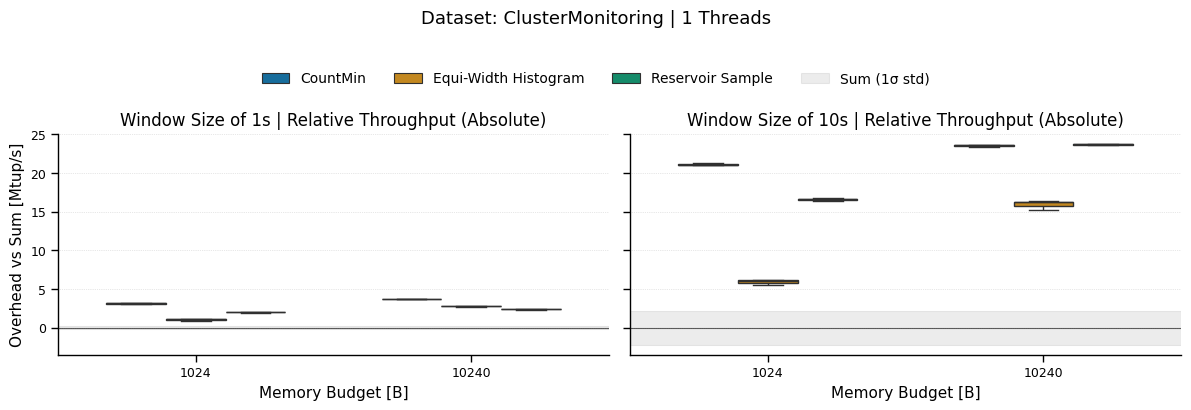

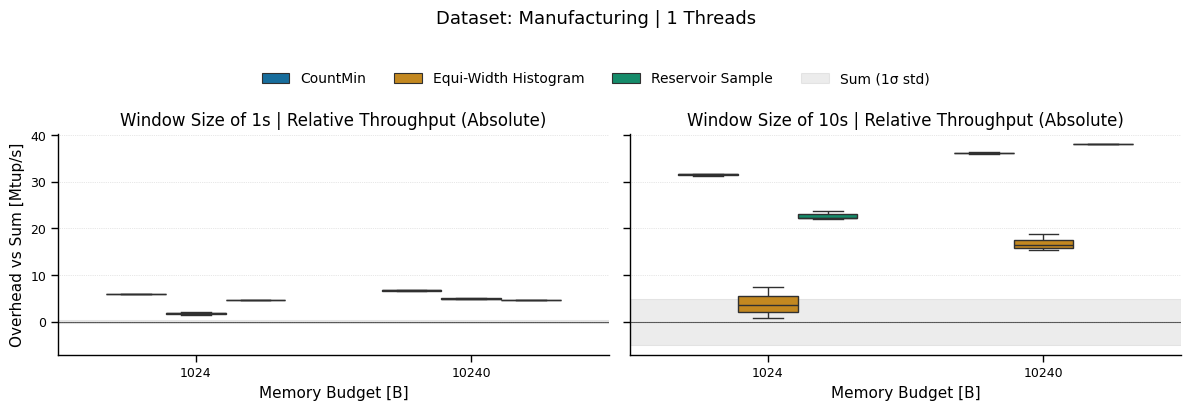

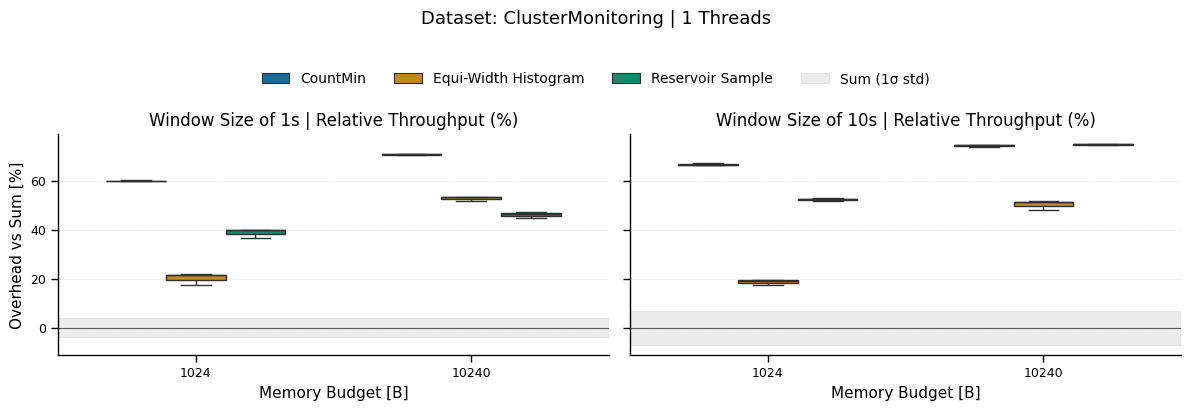

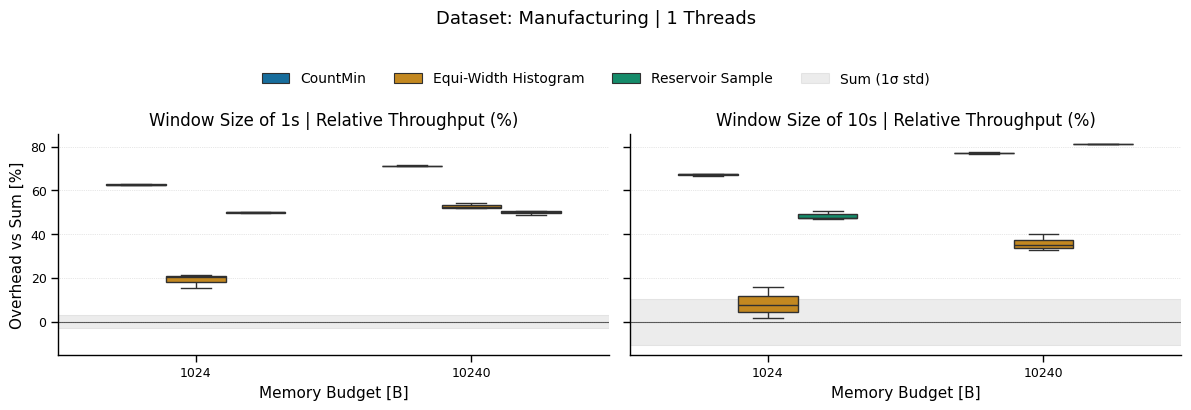

In [4]:
# Plot memory budget vs throughput for threads=1 (both absolute and percentage)
plot_memory_budget_vs_throughput(df_ok, num_threads=1)

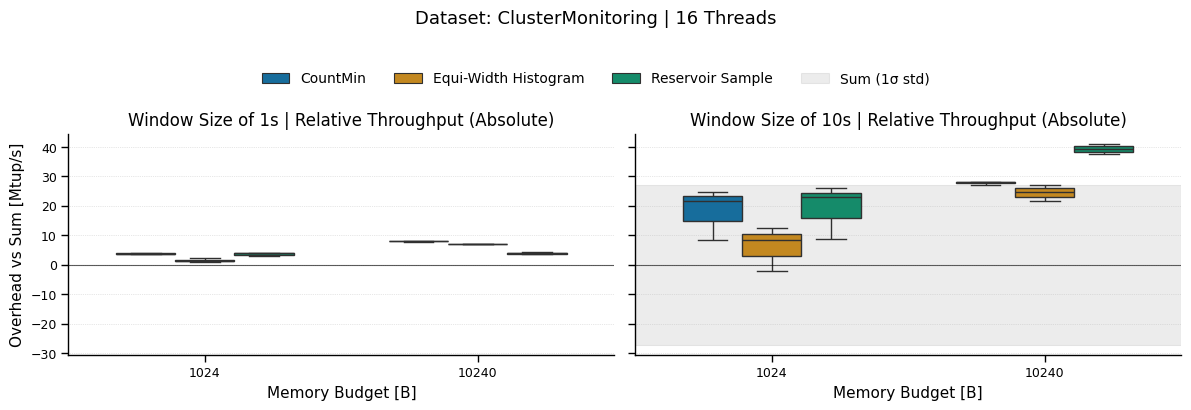

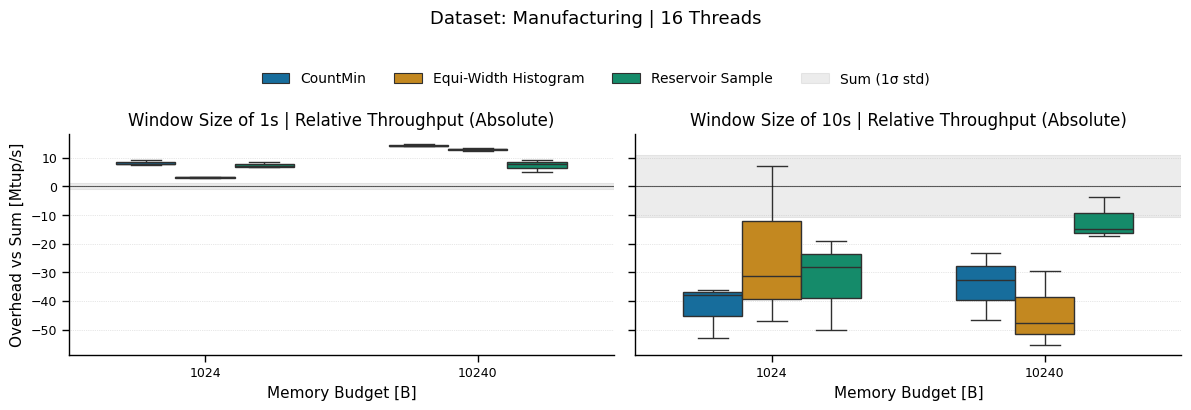

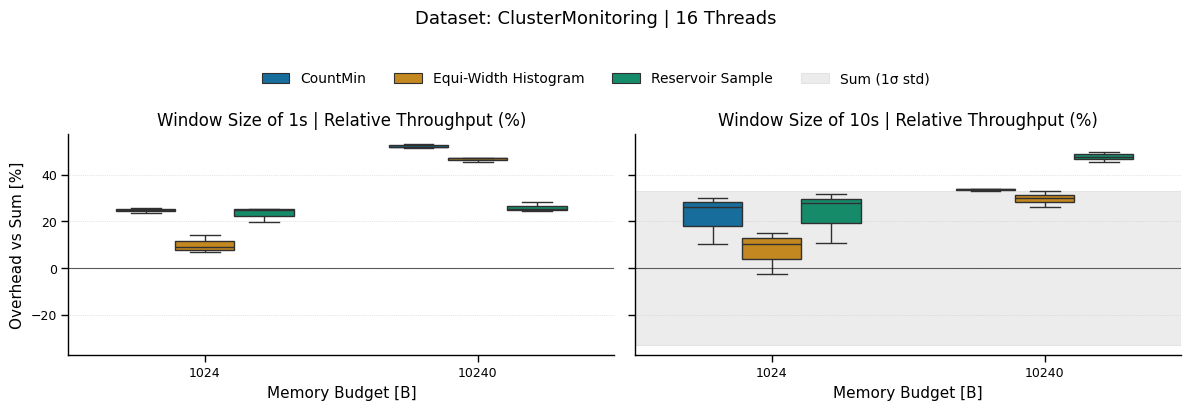

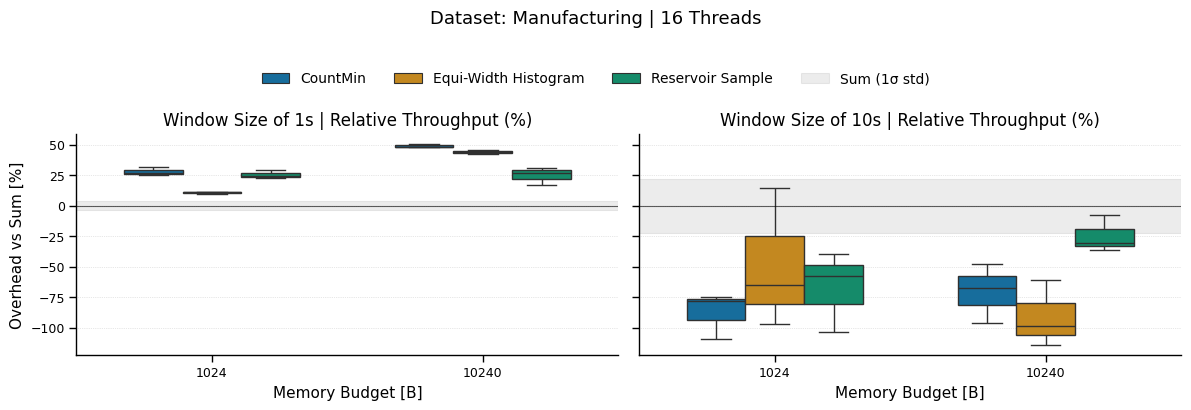

In [5]:
# Plot memory budget vs throughput for threads=16 (both absolute and percentage)
plot_memory_budget_vs_throughput(df_ok, num_threads=16)

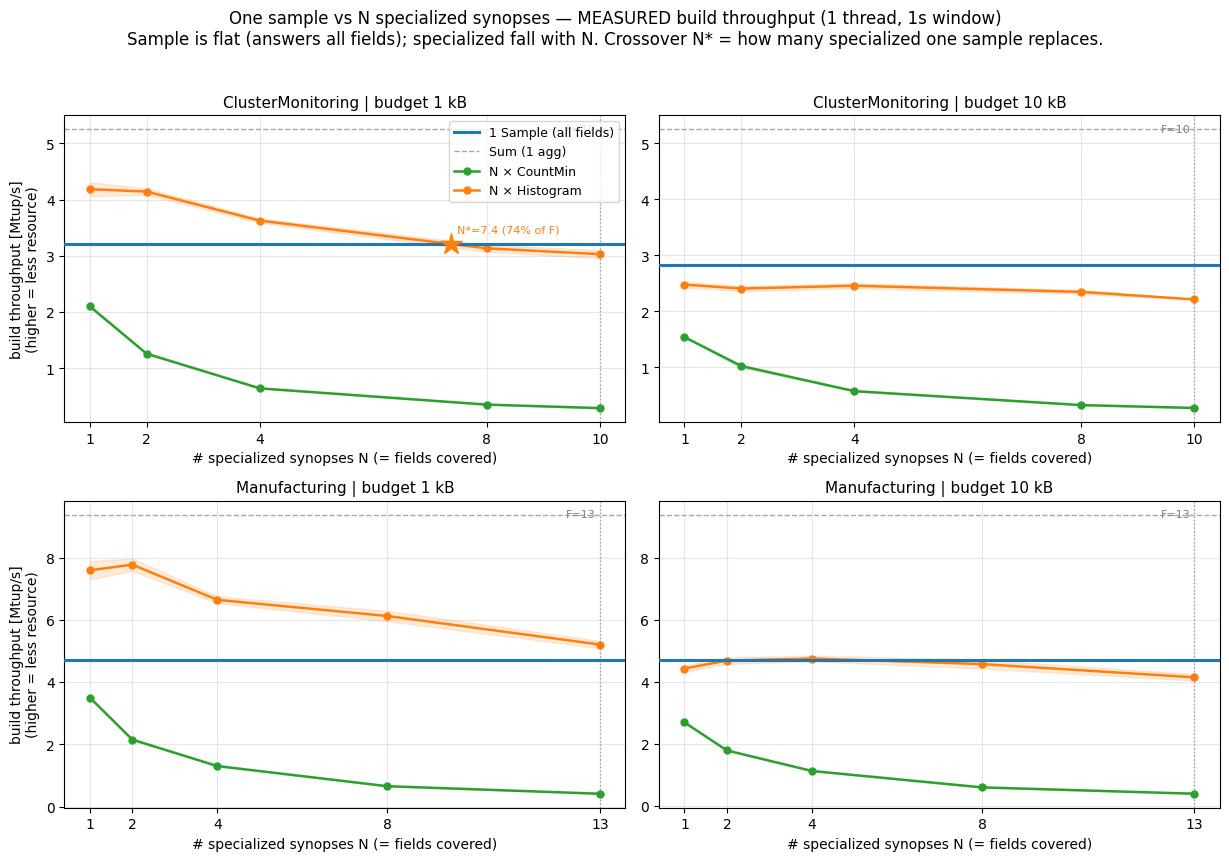

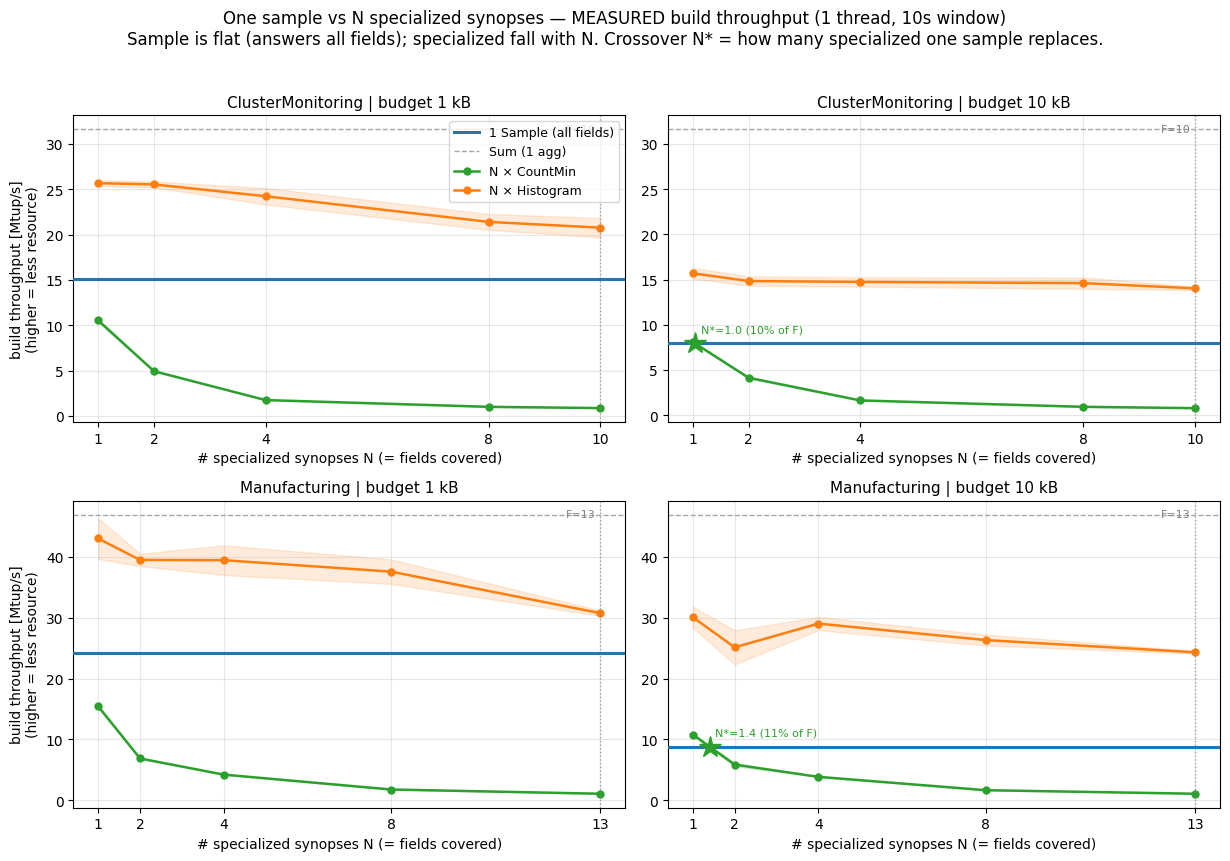

In [7]:
# =============================================================================
# Amortization break-even (MEASURED): one Sample vs N specialized synopses
# =============================================================================
# Measured directly from results_synopsis_amortization.csv: ONE build query
# maintaining N synopses over N distinct fields (one scan, one duration, one
# throughput). A Reservoir sample captures ALL fields at once, so its throughput
# is independent of how many fields are queried (flat line). CountMin / Histogram
# answer one field each, so maintaining N of them costs more per tuple and the
# measured throughput(N) curve falls. Where a specialized curve drops BELOW the
# sample line, a single full-record sample is the cheaper resource choice.
# N* = the (interpolated) number of specialized synopses whose build throughput
# equals one sample; N*/F is the field-coverage crossover.
#
# Lines are means over the runs; the shaded band is ±1σ run-to-run. This replaces
# the earlier additive cost MODEL with the actual N-synopsis measurement. If only
# num_synopses == 1 is present (legacy CSV), the curves collapse to single points
# and no crossover is drawn.
#
# One figure is produced per build window size present in the data; the window
# size is encoded in the saved filename.

AMORT_THREADS = 1          # compute-bound regime; set to 16 for the saturated regime
AMORT_SPEC = [('CountMin', 'N × CountMin', 'tab:green'),
              ('EquiWidthHistogram', 'N × Histogram', 'tab:orange')]

_amdf = df[df['issue'] == 'ok'].copy()
_amdf['tps'] = pd.to_numeric(_amdf['tuplesPerSecond_listener'], errors='coerce') / 1e6
_amdf = _amdf[(_amdf['numberOfWorkerThreads'].astype(str) == str(AMORT_THREADS))
              & _amdf['tps'].notna()]


def _agg_by_n(sub):
    """Return (Ns, means, stds) sorted by num_synopses for one (dataset, budget, type)."""
    g = sub.groupby('num_synopses')['tps'].agg(['mean', 'std']).sort_index()
    return g.index.to_numpy(), g['mean'].to_numpy(), g['std'].fillna(0.0).to_numpy()


def _crossover_n(Ns, means, sample_tps):
    """Interpolated N where the (monotone-decreasing) specialized curve meets sample_tps.

    Returns (n_star, kind) where kind is 'within' (bracketed), 'below_from_start'
    (sample already wins at the smallest N), or 'above_through_end' (specialized
    still wins at the largest N) — or None if not computable.
    """
    if len(Ns) < 1 or not np.isfinite(sample_tps):
        return None
    if means[0] <= sample_tps:
        return Ns[0], 'below_from_start'
    for i in range(len(Ns) - 1):
        if means[i] >= sample_tps >= means[i + 1]:
            frac = (means[i] - sample_tps) / (means[i] - means[i + 1])
            return Ns[i] + frac * (Ns[i + 1] - Ns[i]), 'within'
    return Ns[-1], 'above_through_end'


# One figure per build window size present in the data.
amort_windows = sorted(_amdf['build_window_size_sec'].dropna().unique())

for amort_window in amort_windows:
    _wdf = _amdf[_amdf['build_window_size_sec'] == amort_window]

    # Datasets / budgets to render come from the data itself (so the cell adapts to
    # whatever subset of the sweep has been run).
    amort_datasets = sorted(_wdf['dataset'].unique())
    amort_budgets = sorted(_wdf[_wdf['statistic_type'].isin([s[0] for s in AMORT_SPEC])]
                           ['memory_budget'].astype(int).unique())
    if not amort_budgets:
        amort_budgets = sorted(_wdf['memory_budget'].astype(int).unique())

    if not (amort_datasets and amort_budgets):
        print(f"No amortization data to plot for window {amort_window}s (need ok rows "
              f"at {AMORT_THREADS} thread(s)).")
        continue

    fig, axes = plt.subplots(len(amort_datasets), len(amort_budgets),
                             figsize=(6.2 * len(amort_budgets), 4.2 * len(amort_datasets)),
                             squeeze=False)
    for r, ds in enumerate(amort_datasets):
        dd = _wdf[_wdf['dataset'] == ds]
        # F = field count = the largest N the scaling ladder reached for this dataset.
        spec_rows = dd[dd['statistic_type'].isin([s[0] for s in AMORT_SPEC])]
        F = int(spec_rows['num_synopses'].max()) if not spec_rows.empty else 1
        sum_tps = dd[dd['statistic_type'] == 'Sum']['tps'].mean()
        for c, B in enumerate(amort_budgets):
            ax = axes[r][c]
            db = dd[dd['memory_budget'].astype(int) == B]

            # Flat sample line (one full-record Reservoir; independent of N).
            sample_tps = db[db['statistic_type'] == 'Reservoir']['tps'].mean()
            if np.isfinite(sample_tps):
                ax.axhline(sample_tps, color='tab:blue', lw=2.2, label='1 Sample (all fields)', zorder=5)

            # Faint Sum reference (single aggregation — the cheap-baseline anchor).
            if np.isfinite(sum_tps):
                ax.axhline(sum_tps, color='gray', ls='--', lw=1.0, alpha=0.7, label='Sum (1 agg)', zorder=1)

            for st, lbl, col in AMORT_SPEC:
                sub = db[db['statistic_type'] == st]
                if sub.empty:
                    continue
                Ns, means, stds = _agg_by_n(sub)
                ax.plot(Ns, means, 'o-', color=col, lw=1.8, ms=5, label=lbl)
                ax.fill_between(Ns, means - stds, means + stds, color=col, alpha=0.15, zorder=0)

                co = _crossover_n(Ns, means, sample_tps)
                if co is not None:
                    n_star, kind = co
                    if kind == 'within':
                        ax.plot(n_star, sample_tps, '*', color=col, ms=16, zorder=6)
                        ax.annotate(f'N*={n_star:.1f} ({n_star / F:.0%} of F)',
                                    (n_star, sample_tps), textcoords='offset points',
                                    xytext=(4, 8), fontsize=8, color=col)

            ax.axvline(F, color='gray', ls=':', lw=1, alpha=0.7)
            ax.annotate(f'F={F}', (F, ax.get_ylim()[1]), textcoords='offset points',
                        xytext=(-3, -12), ha='right', fontsize=8, color='gray')
            ax.set_title(f'{ds} | budget {B // 1024} kB', fontsize=11)
            ax.set_xlabel('# specialized synopses N (= fields covered)')
            if c == 0:
                ax.set_ylabel('build throughput [Mtup/s]\n(higher = less resource)')
            ax.grid(True, alpha=0.3)
            n_ticks = sorted(spec_rows['num_synopses'].unique())
            if n_ticks:
                ax.set_xticks(n_ticks)
            if r == 0 and c == 0:
                ax.legend(fontsize=9, loc='upper right')
    fig.suptitle('One sample vs N specialized synopses — MEASURED build throughput '
                 f'({AMORT_THREADS} thread{"s" if AMORT_THREADS != 1 else ""}, {amort_window}s window)\n'
                 'Sample is flat (answers all fields); specialized fall with N. '
                 'Crossover N* = how many specialized one sample replaces.',
                 fontsize=12, y=1.02)
    fig.tight_layout()
    fig.savefig(f'synopsis_amortization_measured_{amort_window}sec.pdf', dpi=300, bbox_inches='tight')
    plt.show()